# **Tarea: Comparación entre SVM y ANN**


## **Actividad 1**
Tomando como ejemplo lo realizado en los tutoriales, en esta tarea utilizarás las funciones de generación de datos de sklearn, como por ejemplo make_blobs, make_moons y make_circles, para crear conjuntos de entrenamiento que se adecuen a distintos modelos.

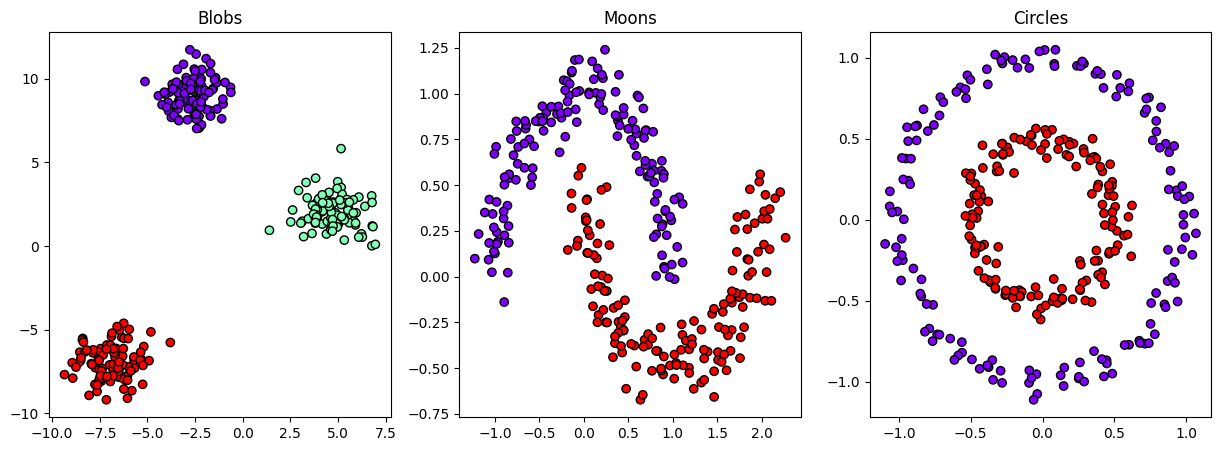

In [9]:
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


datasets = {
    "Blobs": make_blobs(n_samples=300, centers=3, random_state=42, cluster_std=1.0),
    "Moons": make_moons(n_samples=300, noise=0.1, random_state=42),
    "Circles": make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42),
}


plt.figure(figsize=(15, 5))
for i, (name, data) in enumerate(datasets.items()):
    X, y = data
    plt.subplot(1, 3, i + 1)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="rainbow", edgecolor="k")
    plt.title(name)
plt.show()


### **Observación:**

**Blobs:** Tres clusters separados, distribuidos de forma más o menos circular. Este conjunto es ideal para modelos lineales o ligeramente no lineales, ya que los datos son claramente separables.

**Moons:** Dos medias lunas entrelazadas, lo que requiere modelos no lineales (como SVM con kernel RBF o polinomial) para clasificar correctamente las dos clases debido a su estructura curvada.

**Circles:** Dos círculos concéntricos. Este conjunto es un claro ejemplo donde los datos no son separables linealmente, y se necesitará un modelo con capacidad para capturar no linealidad (como SVM con kernel RBF o polinomial).


## **Actividad 2:**

Dividir cada conjunto en subconjuntos de entrenamiento y prueba utilizando train_test_split.

In [3]:
# Dividir cada conjunto de datos en entrenamiento y prueba
splits = {}
for name, (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    splits[name] = (X_train, X_test, y_train, y_test)


## **Actividad 3:**

Entrenamos los siguientes modelos en cada conjunto de datos:

- SVM con kernel lineal

- SVM con kernel RBF

- SVM con kernel polinomial

- SVM con kernel sigmoidal

- MLP con dos capas ocultas

Calculamos la precisión en entrenamiento y prueba para cada modelo en cada conjunto de datos.

In [4]:
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Definir modelos
models = {
    "SVM (lineal)": SVC(kernel="linear", random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", random_state=42),
    "SVM (polinomial)": SVC(kernel="poly", degree=3, random_state=42),
    "SVM (sigmoidal)": SVC(kernel="sigmoid", random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42),
}

# Entrenar y evaluar modelos
results = []
for dataset_name, (X_train, X_test, y_train, y_test) in splits.items():
    for model_name, model in models.items():
        # Entrenar modelo
        model.fit(X_train, y_train)
        # Evaluar en entrenamiento y prueba
        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc = accuracy_score(y_test, model.predict(X_test))
        results.append({
            "Dataset": dataset_name,
            "Model": model_name,
            "Train Accuracy": train_acc,
            "Test Accuracy": test_acc,
        })

# Convertir los resultados en un DataFrame para análisis
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)


    Dataset             Model  Train Accuracy  Test Accuracy
0     Blobs      SVM (lineal)        1.000000       1.000000
1     Blobs         SVM (RBF)        1.000000       1.000000
2     Blobs  SVM (polinomial)        1.000000       1.000000
3     Blobs   SVM (sigmoidal)        1.000000       1.000000
4     Blobs               MLP        1.000000       1.000000
5     Moons      SVM (lineal)        0.858333       0.900000
6     Moons         SVM (RBF)        1.000000       1.000000
7     Moons  SVM (polinomial)        0.920833       0.916667
8     Moons   SVM (sigmoidal)        0.625000       0.700000
9     Moons               MLP        1.000000       1.000000
10  Circles      SVM (lineal)        0.516667       0.433333
11  Circles         SVM (RBF)        1.000000       1.000000
12  Circles  SVM (polinomial)        0.516667       0.433333
13  Circles   SVM (sigmoidal)        0.525000       0.633333
14  Circles               MLP        1.000000       1.000000


### **Observación:**

Los resultados muestran el rendimiento de cada modelo en los tres conjuntos de datos (Blobs, Moons y Circles) tanto en entrenamiento como en prueba.

**Dataset: Blobs**

 - Todos los modelos (SVM con lineal, RBF, polinomial, sigmoidal, y MLP) tienen 100% de precisión en entrenamiento y prueba.

- Los datos en Blobs son linealmente separables, y esto explica por qué todos los modelos logran un rendimiento perfecto. El SVM con kernel lineal es suficiente para separar los clusters, pero los demás modelos también tienen la capacidad de manejar este conjunto de datos de manera óptima.


**Dataset: Moons**

- Mejor modelo: SVM con RBF y MLP, ambos logran 100% de precisión en prueba.
- Buen rendimiento: SVM con kernel polinomial (91.7% en prueba).
- Peor rendimiento: SVM con kernel sigmoidal (70% en prueba) y SVM lineal (90% en prueba).

El conjunto de datos Moons no es linealmente separable, lo que explica por qué SVM con kernel lineal tiene un rendimiento inferior. El kernel RBF y MLP logran capturar la curvatura de los datos, separando perfectamente las dos lunas. El kernel sigmoidal no es ideal para esta forma de datos y tiene el peor rendimiento.

**Dataset: Circles**

- Mejor modelo: SVM con RBF y MLP, ambos logran 100% de precisión en prueba.
- Buen rendimiento: SVM con kernel sigmoidal (63.3% en prueba).
- Peor rendimiento: SVM con kernel lineal y polinomial (43.3% en prueba).

El conjunto Circles presenta dos círculos concéntricos, un problema altamente no lineal. Esto explica por qué el kernel lineal y polinomial tienen un rendimiento muy bajo. El kernel RBF y MLP capturan perfectamente la estructura no lineal, logrando una separación perfecta de las clases. El kernel sigmoidal es un término medio, ya que no se adapta bien a la complejidad de los círculos.

**En Conclusión,** en Blobs todos los modelos funcionan perfectamente. El kernel lineal es suficiente para resolver este problema.En Moons: El SVM con RBF y MLP son los mejores, ya que pueden manejar la no linealidad de las medias lunas.
Y en Circles: El SVM con RBF y MLP destacan nuevamente, demostrando que son los más robustos frente a datos altamente no lineales.


In [10]:
# Encontrar el modelo con mejor precisión en prueba para cada conjunto de datos
best_models = results_df.loc[results_df.groupby("Dataset")["Test Accuracy"].idxmax()]
print(best_models)


    Dataset         Model  Train Accuracy  Test Accuracy
0     Blobs  SVM (lineal)             1.0            1.0
11  Circles     SVM (RBF)             1.0            1.0
6     Moons     SVM (RBF)             1.0            1.0


## **Actividad 4:**

Graficamos las superficies de decisión de los modelos ganadores para cada conjunto de datos. Mostramos cómo cada modelo separa las clases en su respectivo conjunto de datos y justificamos por qué obtiene el mejor rendimiento.


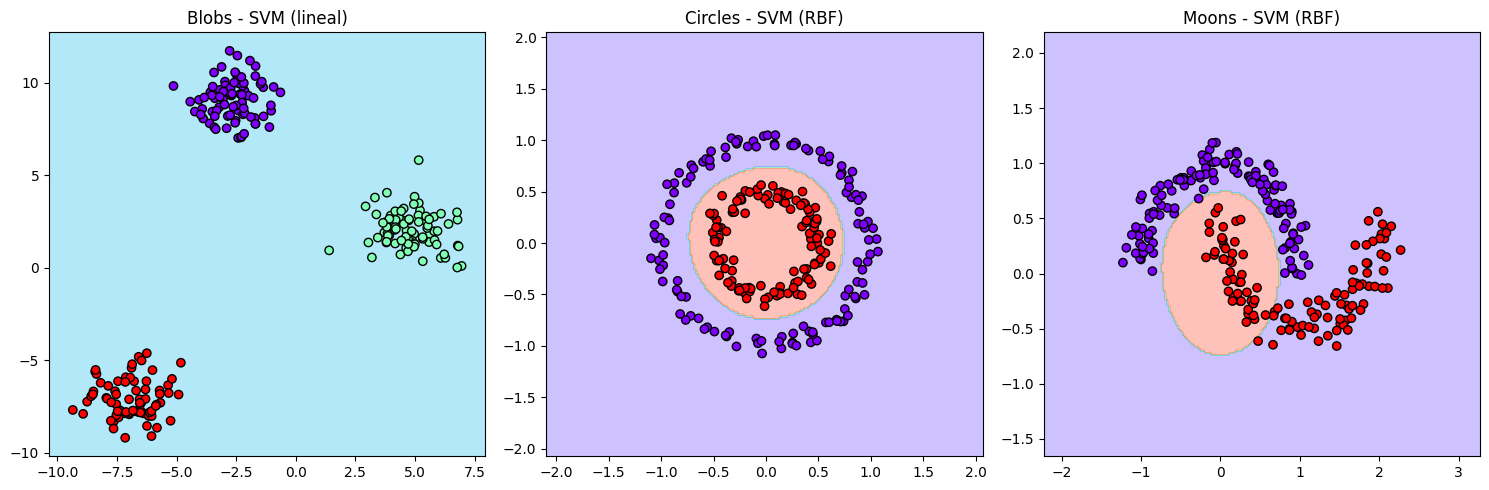

In [11]:
import numpy as np

# Función para graficar superficies de decisión
def plot_decision_boundary(X, y, model, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="rainbow")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="rainbow", edgecolor="k")
    ax.set_title(title)

# Crear las gráficas
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))



for i, (dataset_name, model_name, _, _) in enumerate(best_models.itertuples(index=False)):
    X_train, X_test, y_train, y_test = splits[dataset_name]
    model = models[model_name]
    ax = plt.subplot(1, 3, i + 1)  # Ajustar el índice de los subgráficos
    plot_decision_boundary(X_train, y_train, model, ax, f"{dataset_name} - {model_name}")

plt.tight_layout()
plt.show()




## **Observaciones:**

Las superficies de decisión generadas muestran cómo los modelos ganadores clasifican los datos en cada conjunto, justificando sus rendimientos óptimos.

En el caso de Blobs, el modelo ganador fue el SVM con kernel lineal. Las líneas rectas en la superficie de decisión separan perfectamente los tres clusters, demostrando que este conjunto de datos es linealmente separable. Esto hace que un modelo lineal sea suficiente para clasificar todas las clases con precisión perfecta tanto en entrenamiento como en prueba. La simplicidad de este modelo lo hace el más efectivo para los datos de Blobs.

Para Circles, el SVM con kernel RBF fue el modelo ganador. La superficie de decisión muestra fronteras circulares concéntricas que separan perfectamente las dos clases. Esto se debe a que el kernel RBF transforma los datos a un espacio de mayor dimensión, donde las clases se vuelven separables linealmente. Esta capacidad de modelar estructuras no lineales complejas es esencial para resolver problemas como los círculos concéntricos, explicando su rendimiento perfecto.

En el conjunto de datos Moons, el SVM con kernel RBF también fue el ganador. La superficie de decisión sigue las curvas de las dos lunas, separando perfectamente las clases. Este conjunto de datos no es linealmente separable, pero el kernel RBF adapta las fronteras de decisión a la curvatura de los datos, logrando una clasificación óptima tanto en entrenamiento como en prueba. La flexibilidad del kernel RBF lo convierte en la mejor opción para este problema.

En resumen, el SVM con kernel lineal es ideal para problemas linealmente separables como Blobs, mientras que el kernel RBF se destaca en problemas no lineales como Circles y Moons. Estas visualizaciones confirman que cada modelo seleccionado es el más adecuado para el tipo de datos correspondiente, maximizando la precisión y capturando correctamente la estructura de cada conjunto.